# Pearson correlation matrix — SUS, UEQ, Cognitive value, Intuitiveness, Visualization

Scoring conventions used:
- **SUS** (SUS_1–SUS_9, SUS_10): standard Brooke (1996) scoring. Odd items (SUS_1,3,5,7,9) are positively worded → `score - 1`. Even items (SUS_2,4,6,8,SUS_10) are negatively worded → `5 - score`. Sum of the 10 contributions (0–40) × 2.5 → 0–100 scale.
- **UEQ** (UEQ_1–UEQ_8, 1–7 raw scale): centered by subtracting 4 → −3..+3 scale. No reverse-coding applied (all items assumed same polarity in this dataset). Pragmatic = mean(UEQ_1–UEQ_4), Hedonic = mean(UEQ_5–UEQ_8).
- **Cognitive_value** = mean(P064, P301, P060, P027), raw scale, no reverse-coding.
- **Intuitiveness** = mean(P088, P026, P4026A), raw scale, no reverse-coding.
- **Visualization** = mean(P106,P089,P098,P097, P022A,P067), raw scale, no reverse-coding.

In [12]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import os

print(os.getcwd())

DATA_FILE = "../Data/multigroup_ratings_withNAs.csv"
df = pd.read_csv(DATA_FILE)
df.head()

c:\Users\Eliane\My_codes\GitSuppMaterial\Phase 3 - Scale Validation\Reproduce2 - correlation inter scales and gold standard\Notebooks


,id,seed,stimulus,P026,P088,P4026A,P022A,P067,P089,P097,...,SUS_1,SUS_2,SUS_3,SUS_4,SUS_5,SUS_6,SUS_7,SUS_8,SUS_9,SUS_10
0,14,1886876404,Power BI,6,5,5,7,5.0,6,7,...,4,2,3,1,4,3,3,3,4,4
1,18,823070095,Tableau,7,7,6,6,7.0,5,5,...,3,2,4,1,4,2,4,3,4,2
2,23,113523666,JMP,7,7,7,7,7.0,7,7,...,5,1,5,1,4,1,4,1,5,3
3,24,675873429,Qlik,7,7,7,7,7.0,7,7,...,5,1,5,1,5,1,5,1,5,3
4,25,886668237,Tableau,3,6,6,7,4.0,6,6,...,4,3,3,2,4,2,3,2,5,3


## Compute composite scores

In [13]:
# --- SUS: reverse-code negative items, sum, rescale to 0-100 ---
sus_pos = ['SUS_1', 'SUS_3', 'SUS_5', 'SUS_7', 'SUS_9']
sus_neg = ['SUS_2', 'SUS_4', 'SUS_6', 'SUS_8', 'SUS_10']

sus_contrib = pd.DataFrame(index=df.index)
for c in sus_pos:
    sus_contrib[c] = df[c] - 1
for c in sus_neg:
    sus_contrib[c] = 5 - df[c]

df['SUS'] = sus_contrib.sum(axis=1, min_count=10) * 2.5

In [14]:
# --- UEQ: center 1-7 scale on 0 (range -3..+3), split pragmatic / hedonic ---
ueq_pragmatic_items = ['UEQ_1', 'UEQ_2', 'UEQ_3', 'UEQ_4']
ueq_hedonic_items = ['UEQ_5', 'UEQ_6', 'UEQ_7', 'UEQ_8']

df['UEQ_pragmatic'] = (df[ueq_pragmatic_items] - 4).mean(axis=1)
df['UEQ_hedonic'] = (df[ueq_hedonic_items] - 4).mean(axis=1)

In [15]:
# --- Cognitive value & Intuitiveness: simple mean of raw items ---
cognitive_items = ['P064', 'P301', 'P060', 'P027']
intuitiveness_items = ['P088', 'P026', 'P4026A']
visualization_items = ['P106','P089','P098','P097', 'P022A','P067']  # e.g. ['P0xx', 'P0yy', ...]

df['Cognitive_value'] = df[cognitive_items].mean(axis=1)
df['Intuitiveness'] = df[intuitiveness_items].mean(axis=1)
df['Visualization'] = df[visualization_items].mean(axis=1)


In [6]:
composite_cols = ['SUS', 'UEQ_hedonic', 'UEQ_pragmatic', 'Cognitive_value', 'Intuitiveness', 'Visualization']
composite_df = df[composite_cols]
composite_df.describe()

,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
count,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000
mean,70.542035,1.142699,1.714602,6.067109,5.526549,6.023894
std,14.543399,1.145203,0.919461,0.653939,1.051528,0.552810
min,32.500000,-2.250000,-1.000000,3.750000,2.000000,4.600000
25%,60.000000,0.500000,1.250000,5.750000,5.000000,5.666667
50%,72.500000,1.250000,1.750000,6.000000,5.666667,6.000000
75%,80.000000,2.000000,2.437500,6.500000,6.333333,6.500000
max,100.000000,3.000000,3.000000,7.000000,7.000000,7.000000


## Pearson correlation matrix

Pairwise-complete correlations (rows with `NaN` for a given pair are dropped only for that pair, following pandas' default `.corr()` behavior).

In [16]:
corr = composite_df.corr(method='pearson')
corr.round(3)

,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,1.000,0.281,0.672,0.409,0.598,0.476
UEQ_hedonic,0.281,1.000,0.466,0.561,0.348,0.293
UEQ_pragmatic,0.672,0.466,1.000,0.518,0.695,0.503
Cognitive_value,0.409,0.561,0.518,1.000,0.474,0.592
Intuitiveness,0.598,0.348,0.695,0.474,1.000,0.491
Visualization,0.476,0.293,0.503,0.592,0.491,1.000


In [17]:
def corr_with_pvalues(data):
    cols = data.columns
    r_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    p_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    n_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    for c1, c2 in itertools.combinations_with_replacement(cols, 2):
        sub = data[[c1, c2]].dropna() # pairwise deletion
        x, y = sub.iloc[:, 0], sub.iloc[:, 1]  # positional, safe when c1 == c2
        n = len(sub)
        n_mat.loc[c1, c2] = n_mat.loc[c2, c1] = n
        if n > 1 and x.std() > 0 and y.std() > 0:
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        r_mat.loc[c1, c2] = r_mat.loc[c2, c1] = r
        p_mat.loc[c1, c2] = p_mat.loc[c2, c1] = p
    return r_mat, p_mat, n_mat

r_mat, p_mat, n_mat = corr_with_pvalues(composite_df)
print("r:")
display(r_mat.round(3))
print("p:")
display(p_mat.round(10))
print("n:")
display(n_mat)

r:


,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,1.000,0.281,0.672,0.409,0.598,0.476
UEQ_hedonic,0.281,1.000,0.466,0.561,0.348,0.293
UEQ_pragmatic,0.672,0.466,1.000,0.518,0.695,0.503
Cognitive_value,0.409,0.561,0.518,1.000,0.474,0.592
Intuitiveness,0.598,0.348,0.695,0.474,1.000,0.491
Visualization,0.476,0.293,0.503,0.592,0.491,1.000


p:


,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,0.000000e+00,1.823230e-05,0.0,2.000000e-10,0.000000e+00,0.000000
UEQ_hedonic,1.823230e-05,0.000000e+00,0.0,0.000000e+00,7.870000e-08,0.000007
UEQ_pragmatic,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000
Cognitive_value,2.000000e-10,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000
Intuitiveness,0.000000e+00,7.870000e-08,0.0,0.000000e+00,0.000000e+00,0.000000
Visualization,0.000000e+00,7.232600e-06,0.0,0.000000e+00,0.000000e+00,0.000000


n:


,SUS,UEQ_hedonic,UEQ_pragmatic,Cognitive_value,Intuitiveness,Visualization
SUS,226.0,226.0,226.0,226.0,226.0,226.0
UEQ_hedonic,226.0,226.0,226.0,226.0,226.0,226.0
UEQ_pragmatic,226.0,226.0,226.0,226.0,226.0,226.0
Cognitive_value,226.0,226.0,226.0,226.0,226.0,226.0
Intuitiveness,226.0,226.0,226.0,226.0,226.0,226.0
Visualization,226.0,226.0,226.0,226.0,226.0,226.0


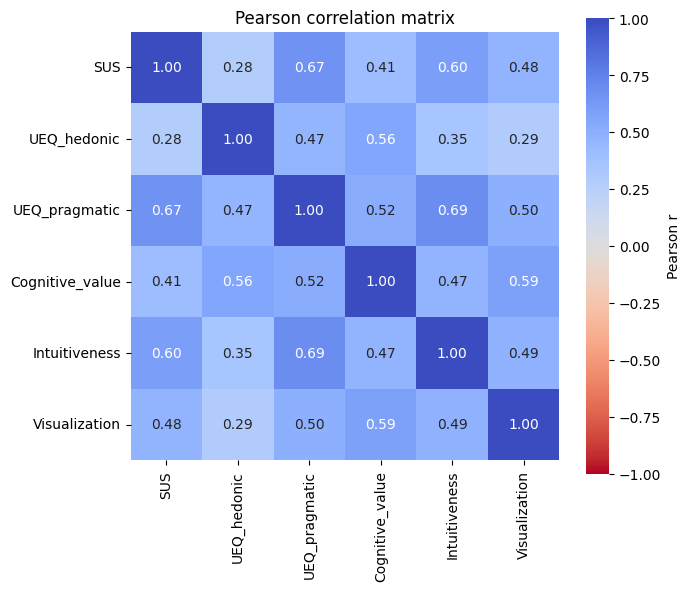

In [18]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm_r", vmin=-1, vmax=1, square=True, cbar_kws={'label': "Pearson r"})
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.savefig("../Data_analysis/correlation_matrix.png", dpi=150)
plt.show()

In [19]:
corr.to_csv("../Data_analysis/pearson_correlation_matrix.csv")
r_mat.to_csv("../Data_analysis/pearson_correlation_matrix_r.csv")
p_mat.to_csv("../Data_analysis/pearson_correlation_matrix_p.csv")
print("Saved: pearson_correlation_matrix.csv, pearson_correlation_matrix_r.csv, pearson_correlation_matrix_p.csv, correlation_matrix.png")

Saved: pearson_correlation_matrix.csv, pearson_correlation_matrix_r.csv, pearson_correlation_matrix_p.csv, correlation_matrix.png
